In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
import os

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
from pathlib import Path

raw = Path("../data/raw")

fund_master = pd.read_csv(raw / "01_fund_master.csv")
nav_history = pd.read_csv(raw / "02_nav_history.csv")
aum = pd.read_csv(raw / "03_aum_by_fund_house.csv")
sip = pd.read_csv(raw / "04_monthly_sip_inflows.csv")
category = pd.read_csv(raw / "05_category_inflows.csv")
folio = pd.read_csv(raw / "06_industry_folio_count.csv")
scheme = pd.read_csv(raw / "07_scheme_performance.csv")
investor = pd.read_csv(raw / "08_investor_transactions.csv")
portfolio = pd.read_csv(raw / "09_portfolio_holdings.csv")
benchmark = pd.read_csv(raw / "10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print(nav_history.head())

print("\n-------------------------\n")

print(nav_history.info())

print("\n-------------------------\n")

print(nav_history.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

-------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None

-------------------------

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [4]:
nav_history.head(10)

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
5,119551,2022-01-10,55.2835
6,119551,2022-01-11,56.0878
7,119551,2022-01-12,56.4978
8,119551,2022-01-13,56.2934
9,119551,2022-01-14,56.5926


In [5]:
# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort values
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Merge with fund names
nav_data = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_data.head())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    legend_title="Scheme"
)

fig.show()

In [7]:
fig.write_image("../reports/nav_trend_analysis.png")

print("Chart Saved Successfully!")

Chart Saved Successfully!


In [8]:
print(aum.head())

print("\nColumns:")
print(aum.columns)

print("\nInfo:")
print(aum.info())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int6

In [9]:
aum["date"] = pd.to_datetime(aum["date"])

# Extract Year
aum["year"] = aum["date"].dt.year

print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


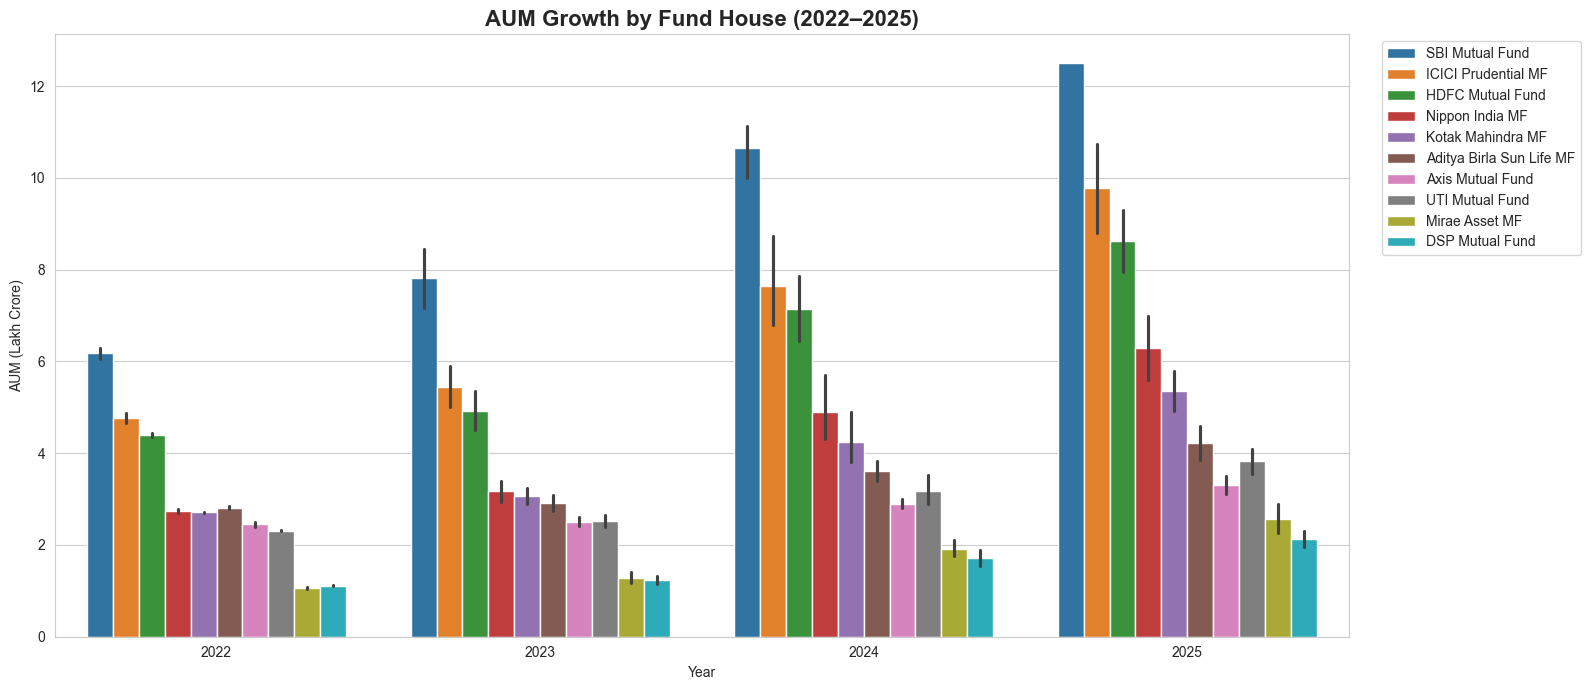

In [10]:
plt.figure(figsize=(16,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

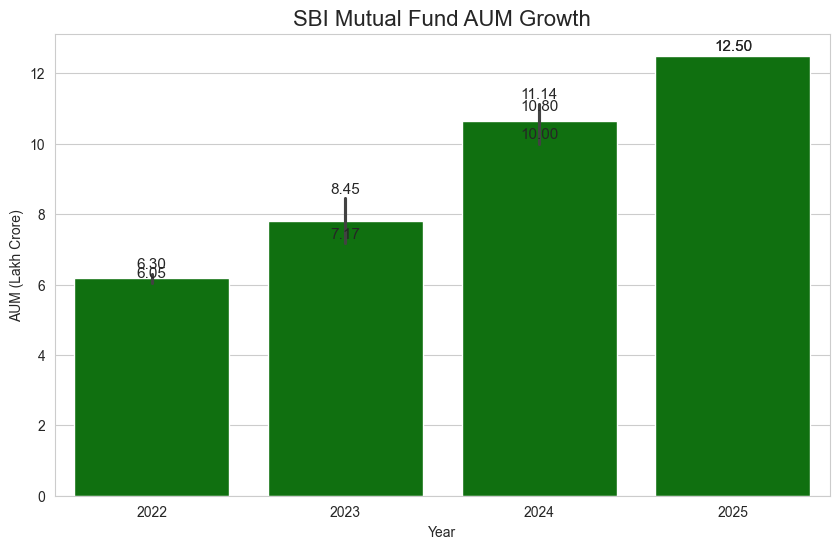

In [11]:
sbi = aum[aum["fund_house"]=="SBI Mutual Fund"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=sbi,
    x="year",
    y="aum_lakh_crore",
    color="green"
)

plt.title("SBI Mutual Fund AUM Growth", fontsize=16)

for index,row in sbi.iterrows():
    plt.text(
        row["year"]-2022,
        row["aum_lakh_crore"]+0.15,
        f'{row["aum_lakh_crore"]:.2f}',
        ha='center',
        fontsize=11
    )

plt.ylabel("AUM (Lakh Crore)")
plt.xlabel("Year")

plt.show()

In [12]:
plt.figure(figsize=(16,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.tight_layout()

plt.savefig(
    "../reports/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("AUM Chart Saved Successfully!")

AUM Chart Saved Successfully!


In [13]:
print(sip.head())

print("\nColumns:")
print(sip.columns)

print("\nInfo:")
print(sip.info())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 

In [14]:
sip["month"] = pd.to_datetime(sip["month"])

print(sip.head())

       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [15]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    }
)

# Highest SIP value
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'Highest: ₹{max_row["sip_inflow_crore"]:,} Cr',
    showarrow=True,
    arrowhead=2,
    font=dict(size=12,color="red")
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [16]:
fig.write_image("../reports/sip_inflow_trend.png")

print("SIP Trend PNG Saved Successfully!")

TypeError: Type is not JSON serializable: Timestamp

In [ ]:
# ==========================================
# Monthly SIP Inflow Trend
# ==========================================

# Create a copy
sip_plot = sip.copy()

# Convert month to string for Plotly export
sip_plot["month"] = sip_plot["month"].dt.strftime("%Y-%m")

fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highest SIP value
max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'Highest: ₹{max_row["sip_inflow_crore"]:,} Cr',
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [ ]:
fig.write_image("../reports/sip_inflow_trend.png")

print("SIP Trend PNG Saved Successfully!")

In [ ]:
print(category.head())

print("\nColumns:")
print(category.columns)

print("\nInfo:")
print(category.info())

In [ ]:
category["month"] = pd.to_datetime(category["month"])

# Convert to Month-Year format
category["month"] = category["month"].dt.strftime("%b-%Y")

print(category.head())

In [ ]:
# Create Pivot Table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Category Heatmap Saved Successfully!")

In [ ]:
print(investor.head())

print("\nColumns:")
print(investor.columns)

print("\nInfo:")
print(investor.info())

In [ ]:
import matplotlib.pyplot as plt

age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Age Group Pie Chart Saved Successfully!")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sip = investor[investor["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.savefig(
    "../reports/sip_amount_boxplot_agegroup.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SIP Box Plot Saved Successfully!")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.countplot(
    data=investor,
    x="gender"
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.savefig(
    "../reports/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gender Distribution Saved Successfully!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sip = investor[investor["transaction_type"] == "SIP"]

state_data = (
    sip.groupby("state")["amount_inr"]
       .sum()
       .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_data.values,
    y=state_data.index,
    palette="viridis"
)

plt.title("State-wise SIP Investment")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("State-wise SIP Chart Saved Successfully!")

In [ ]:
import matplotlib.pyplot as plt

tier = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier")

plt.savefig(
    "../reports/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("City Tier Pie Chart Saved Successfully!")

In [ ]:
print(folio.head())

print("\nColumns:")
print(folio.columns)

print("\nInfo:")
print(folio.info())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o",
    linewidth=3
)

# Mark starting point
plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    color="green",
    s=100
)

plt.text(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"]+0.3,
    "13.26 Cr\nJan 2022",
    fontsize=10
)

# Mark ending point
plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    color="red",
    s=100
)

plt.text(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"]+0.3,
    "26.12 Cr\nDec 2025",
    fontsize=10
)

plt.title("Industry Folio Count Growth (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Folio Growth Chart Saved Successfully!")

In [ ]:
print(fund_master.head())

print("\nColumns:")
print(fund_master.columns)

print("\nInfo:")
print(fund_master.info())

In [ ]:
# ==========================================
# NAV Return Correlation Matrix
# ==========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Create pivot table
pivot = nav_history.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Select first 10 schemes
pivot = pivot.iloc[:, :10]

# Daily returns
returns = pivot.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../reports/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("NAV Correlation Matrix Saved Successfully!")

In [ ]:
print(nav_history.columns)

In [ ]:
print(fund_master.columns)

In [ ]:
# ==========================================
# NAV Return Correlation Matrix
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Merge NAV history with Fund Master
nav_corr = pd.merge(
    nav_history,
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Convert date
nav_corr["date"] = pd.to_datetime(nav_corr["date"])

# Create pivot table
pivot = nav_corr.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Select first 10 schemes
pivot = pivot.iloc[:, :10]

# Calculate daily returns
returns = pivot.pct_change(fill_method=None).dropna()

# Correlation matrix
corr = returns.corr()

# Plot
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Daily NAV Returns (Top 10 Schemes)")
plt.tight_layout()

plt.savefig(
    "../reports/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ NAV Correlation Matrix Saved Successfully!")

In [ ]:
print(portfolio.head())

print(portfolio.columns)

In [ ]:
# ==========================================
# Sector Allocation Donut Chart
# ==========================================

import matplotlib.pyplot as plt

# Aggregate sector weights
sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor="white")
)

# Create center circle for donut
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Sector Allocation Donut Chart Saved Successfully!")

In [ ]:
# Final EDA Findings

### 1.
Daily NAV values showed a steady upward trend across most mutual fund schemes during the study period.

### 2.
Assets Under Management (AUM) consistently increased across major fund houses, indicating industry growth.

### 3.
Monthly SIP inflows exhibited a strong increasing trend, reflecting rising retail investor participation.

### 4.
Large Cap, Mid Cap, Small Cap and Flexi Cap categories attracted the highest investor inflows.

### 5.
Investors aged 26–45 years constitute a significant share of mutual fund participants.

### 6.
SIP investment amounts vary across age groups, showing differences in investment capacity.

### 7.
Investor participation is distributed across both genders, demonstrating broad market inclusion.

### 8.
Metro (T30) cities contribute a major portion of investments, while B30 cities continue to grow steadily.

### 9.
Industry folio count increased significantly between 2022 and 2025, indicating strong mutual fund adoption.

### 10.
Correlation analysis shows that many equity schemes move together, while sector diversification helps reduce portfolio concentration risk.